# Data Exploration

## Authors: Gribaldo Edoardo Silvio, Tichy Vojtech 



## Imports and Data Loading

In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [283]:
X_train = pd.read_csv('vehicles/vehicles-train.csv', low_memory=False)
X_test = pd.read_csv('vehicles/vehicles-test.csv', low_memory=False)

X_train = X_train.drop_duplicates()
X_test = X_test.drop_duplicates()

y_train = X_train['fuelCost08']
y_test = X_test['fuelCost08']

#X_train.drop(columns=['fuelCost08'], inplace=True)
#X_test.drop(columns=['fuelCost08'], inplace=True)

In [284]:
print(f"There are {len(X_train)} rows in X_train")

There are 30000 rows in X_train


In [285]:
print(X_train.columns)

Index(['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08',
       'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2',
       'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U',
       'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders',
       'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08',
       'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA',
       'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD',
       'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make',
       'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity',
       'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA',
       'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'guzzler',
       'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA',
       'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr',
       'createdOn', 'modifiedOn

## Data Cleaning

### Finding and handling columns irrelevant to the task

In order to clean the dataset we would like to know the meaning of the features to understand which ones are relevant to our task and which ones are not. \
We looked online and found the column meaning explanation at this link: https://www.fueleconomy.gov/feg/ws/

Some columns have similar names and indicate the same feature (e.g. U at the end of a column name stands for unrounded while at the beginnning of the column name stands for unadjusted) or often there are columns which are derived from other columns and therefore we have to take care of these as well.

Some of these columns have a lot of `nan` values because are for some specific car types (e.g. electric, bi-fuel etc.), so now we only eliminate the ones that are useless for all types of cars, later on we will split the cars by type and drop some more columns.

In [286]:
# Drop columns related to ids
X_train.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode', 'mpgData'], inplace=True)
X_test.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode', 'mpgData'], inplace=True)

# Drop these columns because they are descriptions of the charger/transmission 
X_train.drop(columns=['c240Dscr', 'c240bDscr', 'trans_dscr'], inplace=True)
X_test.drop(columns=['c240Dscr', 'c240bDscr', 'trans_dscr'], inplace=True)

# Drop these columns because they are combined into comb08
X_train.drop(columns=['highway08', 'city08'], inplace=True)
X_test.drop(columns=['highway08', 'city08'], inplace=True)

# Drop these columns because they are combined into comb08U
X_train.drop(columns=['city08U', 'highway08U'], inplace=True)
X_test.drop(columns=['city08U', 'highway08U'], inplace=True)

# Drop guzzler which is a tax on the fuel emissions but less than 2000 vehicles have this value so it is not useful for the model
X_train.drop(columns=['guzzler'], inplace=True)
X_test.drop(columns=['guzzler'], inplace=True)

# Drop these columns because we have already have the adjusted ones
X_train.drop(columns=['UCity', 'UHighway', 'comb08U'], inplace=True)
X_test.drop(columns=['UCity', 'UHighway', 'comb08U'], inplace=True)

# Drop these columns because are super correlated with the target 
X_train.drop(columns=['co2', 'co2A', 'co2TailpipeGpm', 'barrels08', 'barrelsA08', 'youSaveSpend', 'ghgScore', 'ghgScoreA', 'feScore', 'comb08'], inplace=True)
X_test.drop(columns=['co2', 'co2A', 'co2TailpipeGpm', 'barrels08', 'barrelsA08', 'youSaveSpend', 'ghgScore', 'ghgScoreA', 'feScore', 'comb08'], inplace=True)

# Drop the engine description, the model and the make because there are too many unique values
X_train.drop(columns=['eng_dscr'], inplace=True)
X_test.drop(columns=['eng_dscr'], inplace=True)
# X_train.drop(columns=['eng_dscr', 'model', 'make'], inplace=True)
# X_test.drop(columns=['eng_dscr', 'model', 'make'], inplace=True)


# Delete all the columns which have 1 single value in the whole column
X_train = X_train.loc[:, X_train.nunique() > 1]
X_test = X_test.loc[:, X_test.nunique() > 1]

In [287]:
X_train.describe()

,charge240,cityA08,cityA08U,cityCD,cityE,cityUF,co2TailpipeAGpm,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,fuelCost08,fuelCostA08,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,lv2,lv4,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCityA,UHighwayA,year,charge240b,phevCity,phevHwy,phevComb
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,29891.000000,29894.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.025012,0.616500,0.372864,0.000491,0.202184,0.000760,21.794245,0.690733,0.410354,0.209325,0.000409,0.000742,5.783145,3.336559,1807.021667,98.666667,0.819133,0.480626,0.000292,0.218730,0.000720,1.838100,9.292733,1.768867,6.160033,13.199267,34.381600,0.414967,0.362864,0.040175,0.351890,0.036279,0.770003,1.111066,2002.029433,0.004458,0.075100,0.073233,0.074033
std,0.436744,4.073481,3.723304,0.044698,3.042655,0.020367,104.032037,4.221234,3.775767,3.133487,0.039586,0.019905,1.755709,1.340839,485.410445,469.912314,4.606488,4.019322,0.033203,3.266577,0.019383,5.752095,26.828164,4.316318,9.552842,30.678842,46.276036,8.307338,8.056707,1.227417,8.160266,1.090742,5.600373,6.473490,9.839959,0.144984,2.064672,1.951716,2.003552
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,550.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1984.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.200000,1450.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1995.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,1800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.300000,2050.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,91.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2010.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,127.000000,127.093000,5.350000,122.000000,0.849000,719.000000,117.000000,116.936400,121.000000,4.800000,0.834000,16.000000,8.400000,5550.000000,3900.000000,107.000000,106.531000,4.060000,120.000000,0.813000,49.000000,124.000000,41.000000,55.000000,194.000000,192.000000,294.000000,285.700000,77.504000,303.200000,65.632000,181.560900,152.187800,2017.000000,7.000000,97.000000,79.000000,88.000000


### Column Analysis for duplicity

After dropping clearly unrelevant features we noticed that a lot of columns have similar names and probably indicate the same feature (e.g. U at the end of a column name stands for unrounded while at the beginnning of the column name stands for unadjusted) or often there are columns which are derived from other columns and therefore we have to take care of these as well.

### StartStop

In [288]:
mapping_dict = {'Y': 1, 'N': 0, 'y': 1, 'n': 0}

X_train['startStop'] = X_train['startStop'].map(mapping_dict)
X_test['startStop'] = X_test['startStop'].map(mapping_dict)

X_train['startStop'] = X_train['startStop'].fillna(0)
X_test['startStop'] = X_test['startStop'].fillna(0)

print(X_train['startStop'].value_counts(dropna=False))

startStop
0.0    28654
1.0     1346
Name: count, dtype: int64


### Volume

In [289]:
def compute_interior_volume(df: pd.DataFrame) -> pd.DataFrame:
	"""
	@brief compute the total interior volume of a car out of all accessible columns and drop columns 
		   which will no longer be used in this context
		   
		   dropped columns: hpv, pv2, pv4, hlv, lv2, lv4
		   temp columns: passenger_volume, luggage_volume
		   new column: total_interior_volume

	@param df input dataframe
	@return dataframe with reduced columns
	"""
	df['passenger_volume'] = df['hpv'] + df['pv2'] + df['pv4']

	df['luggage_volume'] = df['hlv'] + df['lv2'] + df['lv4']

	df['total_interior_volume'] = df['passenger_volume'] + df['luggage_volume']

	volume_cols_to_drop = ['hpv', 'pv2', 'pv4', 'hlv', 'lv2', 'lv4', 'passenger_volume', 'luggage_volume']

	df.drop(columns=volume_cols_to_drop, inplace=True)
	
	return df

X_train = compute_interior_volume(X_train)
X_test = compute_interior_volume(X_test)

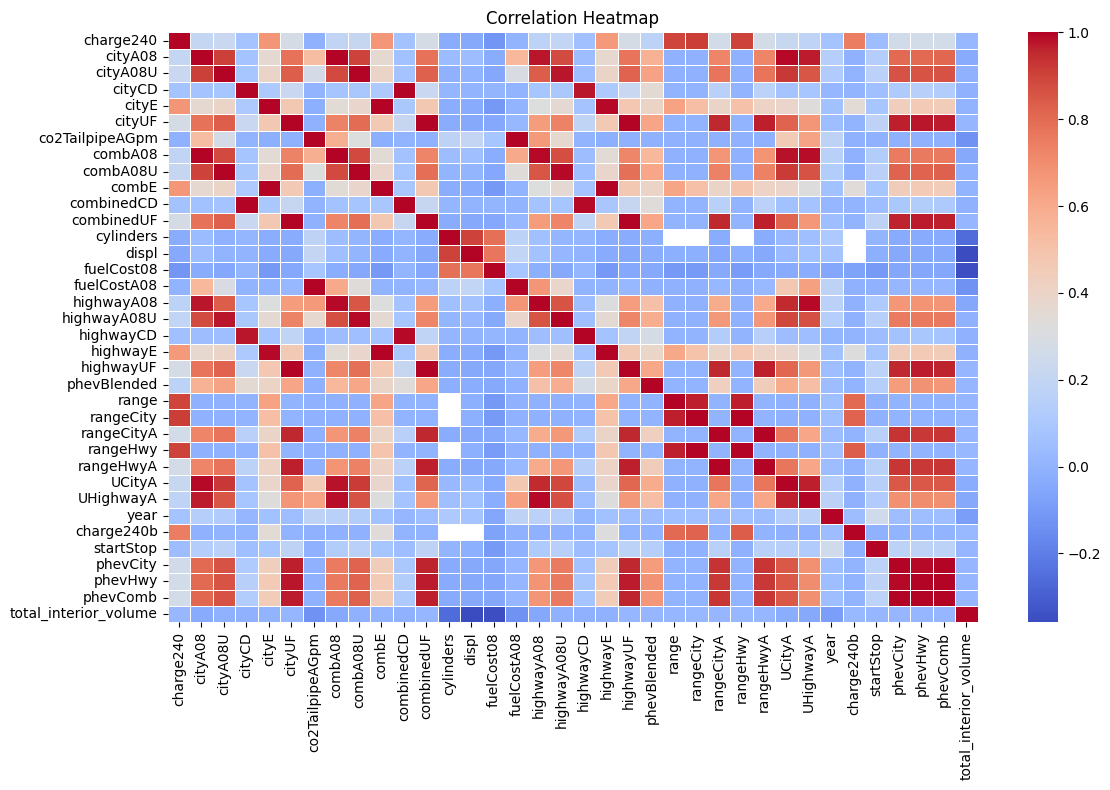

In [290]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(numeric_only=True), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Now let's handle some more difficult columns

### Transmission

In [291]:
def handle_transmission(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Handles the transmission attribute. This column is split into three:
        1. bool column whether the transmission is automatic or manual
        2. number of gears (CVTs have variable gear ratios, will be handled later)
        3. bool column whether the transmission is a CVT
    @param df input dataframe
    @return transformed dataframe
    """
    # Manual / automatic / cvt
    is_manual = df['trany'].str.contains('manual', case=False, na=False)
    is_cvt = df['trany'].str.contains(        
        r'AV|variable', case=False, regex=True, na=False
    )
    # 1 as default for automatic, 0 for manual, 2 for CVT 
    # Put 1 as default because the NaN values were verified by hand were all automatic
    df['automatic'] = np.select((is_cvt, is_manual), [2, 0], default=1)

    # Number of gears
    df['numOfGears'] = df['trany'].str.extract(r'(\d+)')  
    
    return df

In [292]:
X_train = handle_transmission(X_train)
X_test = handle_transmission(X_test)

# Fill the cvt in another class with 10 gears (since they have variable gear ratios it's like they had many gears)
X_train['numOfGears'] = X_train['numOfGears'].fillna(10)
print(X_train['numOfGears'].value_counts(dropna=False))
print(X_train['automatic'].value_counts(dropna=False)) 

numOfGears
4     9625
5     8852
6     6484
3     1902
7     1302
8     1012
10     656
1       96
9       71
Name: count, dtype: int64
automatic
1    19971
0     9160
2      869
Name: count, dtype: int64


In [293]:
# Drop the original 'trany' column since we have already extracted all the useful information from it
X_train.drop(columns=['trany'], inplace=True)
X_test.drop(columns=['trany'], inplace=True)

### Drive

In [294]:
def handle_drive(df: pd.DataFrame) -> pd.DataFrame:
	""" 
	@brief Replace 2WD with FWD or RWD based on other rows with the same car model. 
		   Also reduces duplicit category values.
		   Note: if there is no same model with FWD or RWD, value 2WD then stays the same

	@param df input dataframe
	@return modified dataframe
	"""
	
	drive_mapping = {
    '4-Wheel or All-Wheel Drive' : 'All-Wheel Drive',
    '4-Wheel Drive' : 'All-Wheel Drive',
	}

	df['drive'] = df['drive'].replace(drive_mapping)

	two_wheel_car_list = df[df['drive'] == '2-Wheel Drive']
	two_wheel_car_list = two_wheel_car_list[['make', 'model']].sort_values(['make', 'model'])
	
	for car in two_wheel_car_list.itertuples(index=False):
		model_cars = df[(df['model'].str.contains(car.model, na=False, case=False)) &
							((df['drive'] == 'Rear-Wheel Drive') | (df['drive'] == 'Front-Wheel Drive') | (df['drive'] == '2-Wheel Drive'))]
		model_cars_val_cnt = model_cars.drive.value_counts()
		model_cars = model_cars[model_cars['drive'] == '2-Wheel Drive'].index
		if len(model_cars_val_cnt) == 2:
			df.loc[model_cars, 'drive'] = model_cars_val_cnt.index[0]

	return df

In [295]:
X_train = handle_drive(X_train)
X_test = handle_drive(X_test)
X_train['drive'].value_counts(dropna=False)

drive
Front-Wheel Drive          10332
Rear-Wheel Drive           10274
All-Wheel Drive             7975
NaN                         1189
Part-time 4-Wheel Drive      142
2-Wheel Drive                 88
Name: count, dtype: int64

We would like to distinguish whether a given car is either:
1. Front-Wheel Drive 
2. Rear-Wheel Drive 
3. both Front and Rear Wheel Drive (All wheel Drive)

So for cars with value `2-Wheel Drive` we would like to discover, whether they are type 1. or type 2.
We can also later try to fill the values for `Nan` based on available information found on the internet.

In [296]:
X_train[X_train['drive'] == '2-Wheel Drive'].model.unique()

<StringArray>
[               'RAV4 EV', 'Explorer USPS Electric',              'Truck 2WD',
     'Vandura G15/25 2WD',          'Cargo Van 2WD',    'E150 Club Wagon 2WD',
                'Van 2WD',       'FJ8c Post Office',      'DJ Po Vehicle 2WD',
   'S10 Utility Body 2WD',   'S15 Utility Body 2WD',     'Funeral Coach  2WD',
         'Pathfinder 2WD',           'S10 Electric']
Length: 14, dtype: str

In [297]:
nan_models = X_train.loc[X_train['drive'].isna(), ['model', 'make', 'year']]
print(nan_models)

                             model                           make  year
7138                      Altra EV                         Nissan  2000
8144                         Th!nk                           Ford  2001
8147                    Hyper-Mini                         Nissan  2001
18217           Spider Veloce 2000                     Alfa Romeo  1984
18218                         X1/9                        Bertone  1984
18219                     Corvette                      Chevrolet  1984
18220                     Corvette                      Chevrolet  1984
18221                        300ZX                         Nissan  1984
18222                        300ZX                         Nissan  1984
18223                        300ZX                         Nissan  1984
18224                        300ZX                         Nissan  1984
18225                          EXP                           Ford  1984
18227                          EXP                           For

We go check online which are rear-wheeled and which are front-wheeled.

In [298]:
rwd_cars = [
    'Corvette', '300ZX', 'RX-7', '911 SC', '928 S', '944', 'Starion', 'Conquest', 
    'Spider Veloce', 'Spider Pininfarina', 'X1/9', 'Countach', 'Esprit', 'Avanti II', 
    'Biturbo', 'Quattroporte', 'XJ', 'XJS', '380SL', '500SEC', '500SEL', '300D', 
    '300SD', '300TD', 'Lagonda', 'Saloon', 'Vantage', 'Volante', 'Corniche', 
    'Silver Spirit', 'Camargue', 'Kenyon',
    'Camaro', 'Firebird', 'Mustang', 'Capri', 'Thunderbird', 'Cougar', 'Grand Prix', 
    'Monte Carlo', 'Regal', 'Cutlass Supreme', 'Bonneville', 'Diplomat', 'Gran Fury', 
    'Newport', 'Fifth Avenue', 'LTD Crown Victoria', 'Grand Marquis', 'Town Car', 
    'Impala', 'Caprice', 'Parisienne', 'Delta 88', 'Ninety-Eight', 'LeSabre',
    'Fiero', 'Hyper-Mini'
    'Truck 2WD', 'Vandura G15/25 2WD', 'Cargo Van 2WD', 'E150 Club Wagon 2WD', 
    'Van 2WD', 'FJ8c Post Office', 'DJ Po Vehicle 2WD', 'S10 Utility Body 2WD', 
    'S15 Utility Body 2WD', 'Funeral Coach  2WD'
]

fwd_cars = [
    'Civic', 'Accord', 'Prelude', 'CRX', 'Sentra', 'Maxima', 'Stanza', 'Pulsar', 
    'Camry', 'Corolla', 'Tercel', 'Starlet', 'GLC', '626', 'Cordia', 'Tredia', 
    'Colt', 'Precis', 'I-Mark', 'Impulse', 'Rabbit', 'Jetta', 'Scirocco', 'Quantum', 
    '4000', '5000S', 'Coupe GT', '900', '18i', 'Fuego', 'Alliance', 'Encore', '505', '604',
    'Cavalier', 'Celebrity', 'Citation II', 'Skyhawk', 'Skylark', 'Century', 'Firenza', 
    'Omega', 'Phoenix', '6000', 'Cimarron', 'Eldorado', 'Seville', 'Riviera', 'Toronado',
    'Aries', 'Reliant', 'LeBaron', 'Daytona', 'Laser', 'Charger', 'Turismo', 'Omni', 
    'Horizon', '600', 'Tempo', 'Topaz', 'Escort', 'Lynx', 'EXP', 'LTD', 'Marquis',
    'Altra EV', 'Th!nk',
    'RAV4 EV', 'Explorer USPS Electric', 'Pathfinder 2WD', 'S10 Electric'

]

In [299]:
X_train.loc[X_train['model'].str.contains('quattro|4WD', case=False, na=False), ['fwd', 'rwd']] = 1

X_train['is_front'] = np.where(
    X_train['drive'].str.contains('Front|All|4-Wheel|Part', case=False, na=False) |
    (X_train['drive'].eq('2-Wheel Drive') & X_train['model'].isin(fwd_cars)),
    1, 0
)
X_test['is_front'] = np.where(
    X_test['drive'].str.contains('Front|All|4-Wheel|Part', case=False, na=False) |
    (X_test['drive'].eq('2-Wheel Drive') & X_test['model'].isin(fwd_cars)),
    1, 0
)       

X_train['is_rear'] = np.where(
    X_train['drive'].str.contains('Rear|All|4-Wheel|Part', case=False, na=False) |
    (X_train['drive'].eq('2-Wheel Drive') & ~X_train['model'].isin(rwd_cars)),
    1, 0
)

X_test['is_rear'] = np.where(
    X_test['drive'].str.contains('Rear|All|4-Wheel|Part', case=False, na=False) |
    (X_test['drive'].eq('2-Wheel Drive') & ~X_test['model'].isin(rwd_cars)),        
    1, 0
)

In [300]:
# Drop the original 'drive' column since we have already extracted all the useful information from it
X_train.drop(columns=['drive'], inplace=True)
X_test.drop(columns=['drive'], inplace=True)

### Size

In [301]:
def encode_vclass(df):
    """
    Evaluates the VClass column of the provided dataframe and 
    maps it to a numerical Size column (1-11).
    """
    # Notice we use 'df' here so it works for ANY dataframe passed into the function!
    conditions = [
        df['VClass'].str.contains('Two Seater', case=False, na=False),          # 1
        df['VClass'].str.contains('Minicompact', case=False, na=False),         # 2
        df['VClass'].str.contains('Subcompact', case=False, na=False),          # 3
        df['VClass'].str.contains('Compact', case=False, na=False),             # 4
        df['VClass'].str.contains('Midsize', case=False, na=False),             # 5
        df['VClass'].str.contains('Large', case=False, na=False),               # 6
        df['VClass'].str.contains('Wagon', case=False, na=False),               # 7
        df['VClass'].str.contains('Sport Utility', case=False, na=False),       # 8
        df['VClass'].str.contains('Pickup', case=False, na=False),              # 9
        df['VClass'].str.contains('Van', case=False, na=False),                 # 10
        df['VClass'].str.contains('Special Purpose', case=False, na=False)      # 11
    ]

    choices = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

    df['Size'] = np.select(conditions, choices, default=5)
    
    df.drop(columns=['VClass'], inplace=True)
    
    return df

In [302]:
X_train = encode_vclass(X_train)
X_test = encode_vclass(X_test)

### FuelType

In [303]:
def handleFuelType(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief simplifies 'fuelType' attribute by reducing the overall number of values the attribute can have,
           adds a new column 'premium' which says, whether premium fuel was used or not
           fills all missing values in 'startStop' column as False

           initially the 'fuelType' can have all of these values:

                Regular
                Premium
                Gasoline or E85
                Diesel
                Premium or E85
                Electricity
                Midgrade
                CNG
                Gasoline or natural gas
                Premium Gas or Electricity
                Premium and Electricity
                Regular Gas and Electricity
                Gasoline or propane
                Regular Gas or Electricity

           this function reduces the possible values to:

                Gas
                Diesel
                Hybrid
                Electric
                CNG
                FFV

           plus introduces 'premium' boolean column.

    @param df input dataframe
    @return transformed dataframe        
    """
    df['premium'] = df['fuelType'].isin(["Premium","Premium or E85","Premium Gas or Electricity","Premium and Electricity"])
    df['premium'] = df['premium'].astype('category')

    reduced_gas_types = {
        'Regular' : 'Gas',
        'Premium' : 'Gas',
        'Gasoline or E85' : 'Gas',
        'Premium or E85' : 'Gas',
        'Midgrade' : 'Gas',
        'Gasoline or natural gas' : 'Bifuel',
        'Gasoline or propane' : 'Bifuel',
        'Premium Gas or Electricity' : 'Hybrid',
        'Regular Gas and Electricity' : 'Hybrid',
        'Regular Gas or Electricity' : 'Hybrid',
        'Premium and Electricity' : 'Hybrid'
    }
    df['fuelType'] = df['fuelType'].replace(reduced_gas_types)
    df.loc[df['atvType'] == 'FFV', 'fuelType'] = 'FFV'
    df.loc[df['fuelType'] == 'Diesel', 'fuelType1'] = 'Diesel'

    df['startStop'].fillna(False)

    return df

X_train = handleFuelType(X_train)
X_test = handleFuelType(X_test)

gas_cars = X_train[X_train['fuelType'] == 'Gas'].copy() 
ffv_cars = X_train[X_train['fuelType'] == 'FFV'].copy()
diesel_cars = X_train[X_train['fuelType1'] == 'Diesel'].copy()
hybrid_cars = X_train[X_train['fuelType'] == 'Hybrid'].copy()
ev_cars = X_train[X_train['fuelType1'] == 'Electricity'].copy()
bi_cars = X_train[X_train['fuelType'] == 'Bifuel'].copy()

cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars]

In [304]:
X_train['fuelType'].value_counts()

fuelType
Gas            27657
FFV             1282
Diesel           821
Electricity      106
CNG               60
Hybrid            46
Bifuel            28
Name: count, dtype: int64

These cars were probably misclassified into `gas_cars` but actually are `Hybrid`, let's run an intersection between the columns of hybrid cars and gas cars to see if they have a lot in common.

In [305]:
# For gas cars we have some cars which have non-null values in the 'evMotor' column (that doesn't happen in diesel and ffv cars)

misclassified_cars = gas_cars[gas_cars["evMotor"].notna()]

In [306]:
len(set(hybrid_cars.columns.to_list()) & set(gas_cars.columns.to_list()))

52

In [307]:
gas_cars = gas_cars[gas_cars["evMotor"].isna()]

Since there are 14 columns in `hybrid_cars` that are not present in `gas_cars`, moving the samples from one dataFrame to another would be difficult and would create a lot of noise. \
As a matter of fact the 360 samples of hybrid cars misclassified into gas cars will be simply discarded.

In [308]:
gas_cars = gas_cars.loc[:, gas_cars.nunique() > 1]
gas_cars_test = X_test[X_test['fuelType'] == 'Gas'].copy()
gas_cars_test = gas_cars_test.loc[:, gas_cars_test.nunique() > 1]

ffv_cars = ffv_cars.loc[:, ffv_cars.nunique() > 1]
ffv_cars_test = X_test[X_test['fuelType'] == 'Gas'].copy()
ffv_cars_test = ffv_cars_test.loc[:, ffv_cars_test.nunique() > 1]

diesel_cars = diesel_cars.loc[:, diesel_cars.nunique() > 1]
diesel_cars_test = X_test[X_test['fuelType1'] == 'Diesel'].copy()
diesel_cars_test = diesel_cars_test.loc[:, diesel_cars_test.nunique() > 1]

hybrid_cars = hybrid_cars.loc[:, hybrid_cars.nunique() > 1]
hybrid_cars_test = X_test[X_test['fuelType'] == 'Hybrid'].copy()
hybrid_cars_test = hybrid_cars_test.loc[:, hybrid_cars_test.nunique() > 1]

ev_cars = ev_cars.loc[:, ev_cars.nunique() > 1]
ev_cars_test = X_test[X_test['fuelType1'] == 'Electricity'].copy()
ev_cars_test = ev_cars_test.loc[:, ev_cars_test.nunique() > 1]

bi_cars = bi_cars.loc[:, bi_cars.nunique() > 1]
bi_cars_test = X_test[X_test['fuelType'] == 'Bifuel'].copy()
bi_cars_test = bi_cars_test.loc[:, bi_cars_test.nunique() > 1]


In [309]:
cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars, bi_cars]
cars_names = ['Gas', 'FFV', 'Diesel', 'Hybrid', 'EV', 'Bifuel']

# Print the column counts
for name, car_df in zip(cars_names, cars_types):
    print(f"{len(car_df)} {name} cars with {len(car_df.columns)} columns")

27297 Gas cars with 15 columns
1282 FFV cars with 26 columns
821 Diesel cars with 13 columns
46 Hybrid cars with 41 columns
106 EV cars with 19 columns
28 Bifuel cars with 24 columns


In [310]:
fuel_mapping = {
    'EV': 0,
    'Hybrid': 1,
    'Bifuel': 2,
    'FFV': 3,
    'Diesel': 4,
    'Gas': 5
}

X_train['fuel'] = X_train['fuelType1'].fillna('')
X_test['fuel'] = X_test['fuelType1'].fillna('')

X_train['fuel'] = X_train['fuel'].map(fuel_mapping)
X_test['fuel'] = X_test['fuel'].map(fuel_mapping)

In [311]:
len(set(hybrid_cars.columns.to_list()) - set(gas_cars.columns.to_list()))

27

## Utils 

In [312]:
def plot_distribution(df, name):
    
    numeric_cols = df.select_dtypes(include=np.number).columns


    if df.empty or len(numeric_cols) == 0:
        print(f"No numeric features to plot for '{name}' (empty dataset or no numeric columns).")
    else:
        n = len(numeric_cols)
        ncols = 4
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
            axes[i].set_title(col)

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f"Feature Distributions - {name}", y=1.02)
        plt.tight_layout()
        plt.show()

## Gas Cars

In [313]:
gas_cars.head(5)

,cylinders,displ,fuelCost08,fuelType1,make,model,year,startStop,total_interior_volume,automatic,numOfGears,is_front,is_rear,Size,premium
0,4.0,2.0,1550,Regular Gasoline,Alfa Romeo,Spider Veloce 2000,1985,0.0,0,0,5,0,1,1,False
1,12.0,4.9,2900,Regular Gasoline,Ferrari,Testarossa,1985,0.0,0,0,5,0,1,1,False
2,4.0,2.2,1200,Regular Gasoline,Dodge,Charger,1985,0.0,96,0,5,1,0,3,False
3,8.0,5.2,2900,Regular Gasoline,Dodge,B150/B250 Wagon 2WD,1985,0.0,0,1,3,0,1,10,False
4,4.0,2.2,2050,Premium Gasoline,Subaru,Legacy AWD Turbo,1993,0.0,104,0,5,1,1,4,True


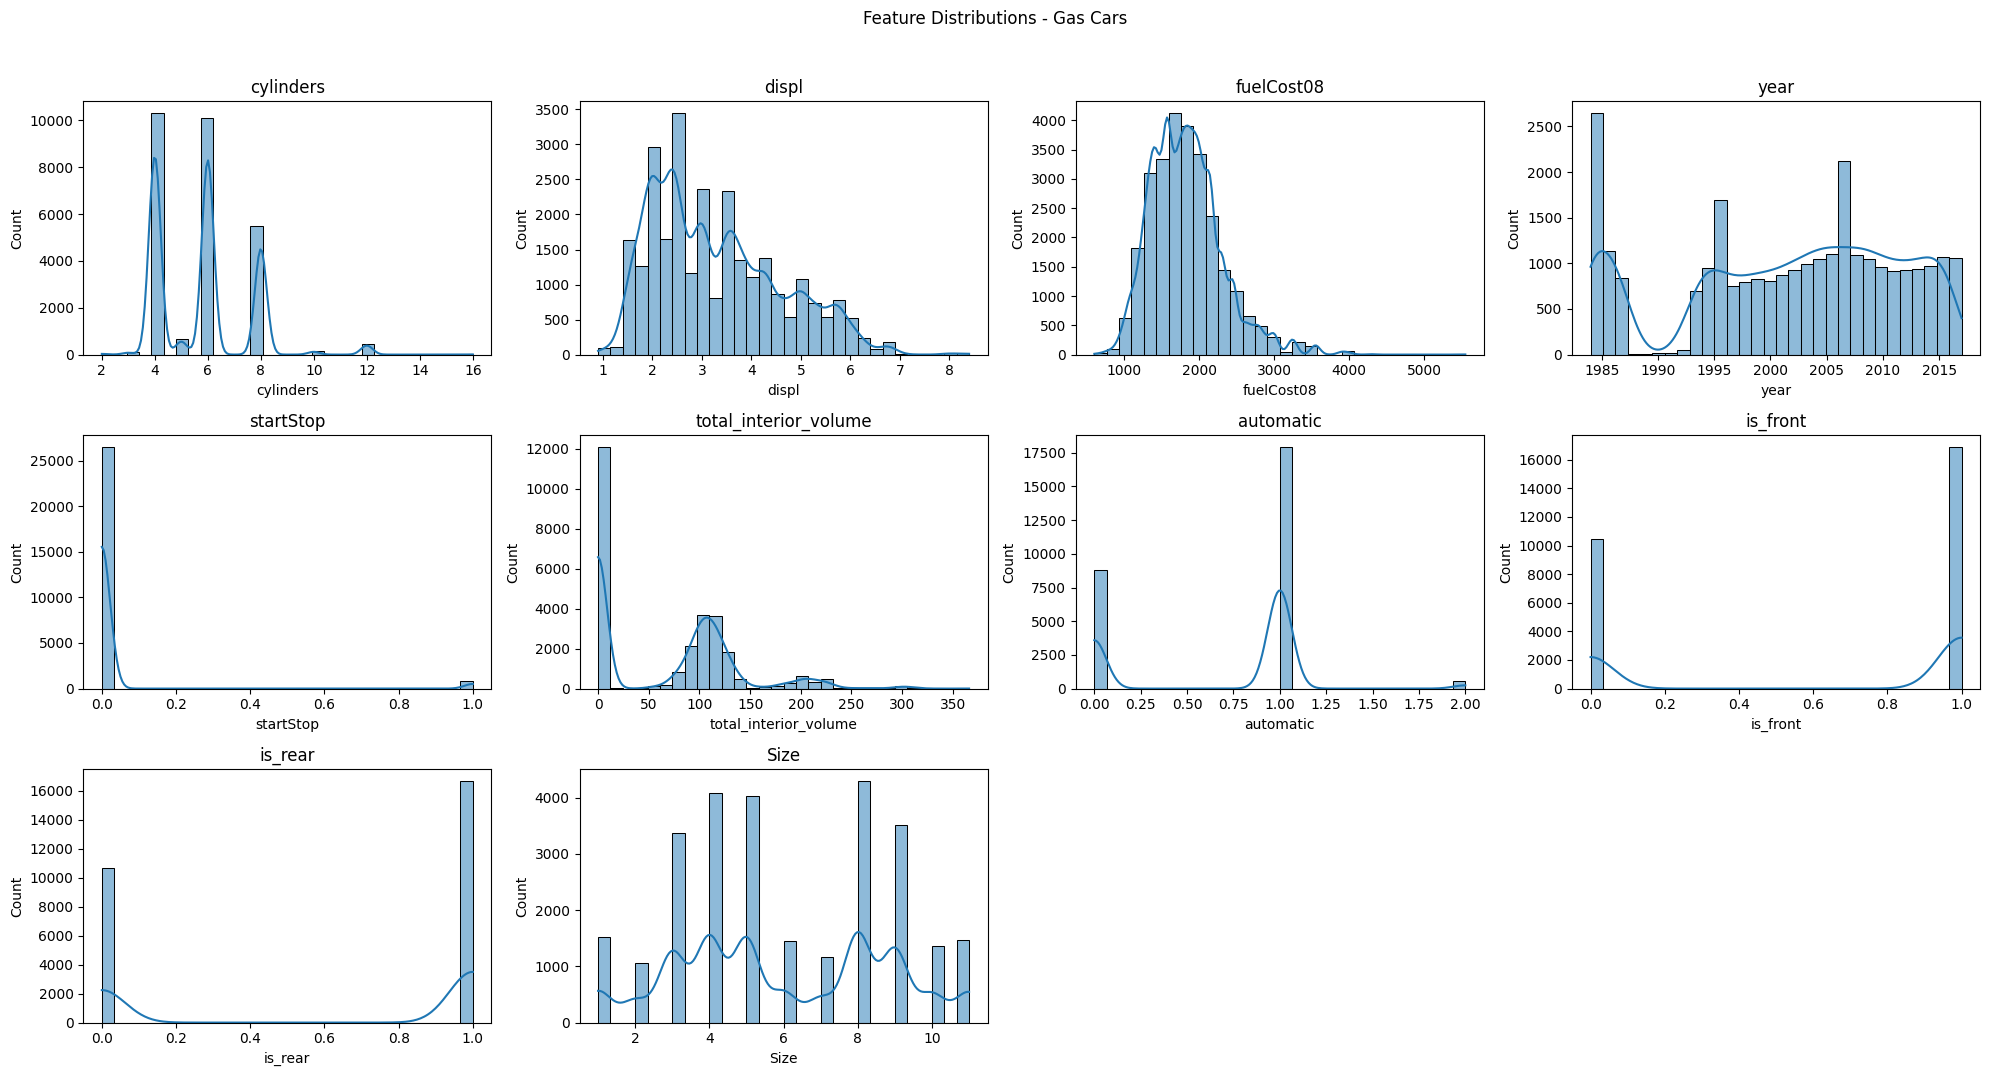

In [314]:
plot_distribution(gas_cars, "Gas Cars")

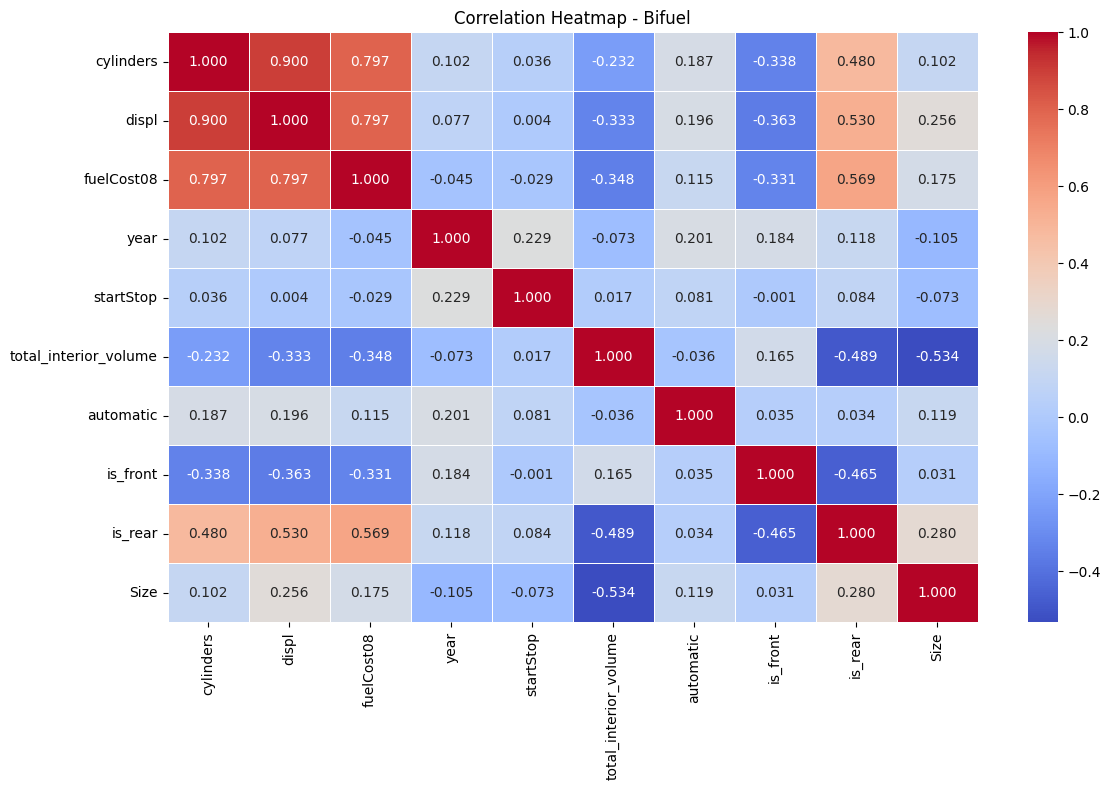

In [315]:
numeric_cols = gas_cars.select_dtypes(include=np.number).columns

if gas_cars.empty or len(numeric_cols) < 2:
    print(f"Cannot plot correlation heatmap for '{name}': not enough numeric data.")
else:
    corr = gas_cars[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.5, fmt='.3f', annot=True)
    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

In [316]:
# Drop columns with very high pairwise correlation (|corr| >= 0.95)
corr_matrix = gas_cars[numeric_cols].corr().abs()

# Keep only upper triangle of correlation matrix (without diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop
high_corr_cols = [col for col in upper.columns if (upper[col] >= 0.95).any()]

print(f"Columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

# Drop from gas_cars
gas_cars.drop(columns=high_corr_cols, inplace=True)
gas_cars_test.drop(columns=high_corr_cols, inplace=True)

# Refresh numeric_cols after dropping
numeric_cols = gas_cars.select_dtypes(include=np.number).columns
print(f"Remaining numeric columns: {len(numeric_cols)}")

Columns to drop (0): []
Remaining numeric columns: 10


In [317]:
gas_cars.select_dtypes(include=['object', 'category', 'str']).describe()

,fuelType1,make,model,numOfGears,premium
count,27297,27297,27297,27297,27297
unique,3,110,2945,8,2
top,Regular Gasoline,Chevrolet,Mustang,4,False
freq,18655,2319,154,8808,18719


### What to do with the other (categorical) columns?
- drive	-> keep
- eng_dscr	-> not sure whether its worth keeping
- fuelType1	-> we already grouped the cars based on fuelType would personally discard this
- make	-> maybe model is more relevant, probably discard
- model	-> maybe useful
- mpgData -> lots of missing data N
- trany	-> very useful attribute
- VClass -> also interesting attribute, but the number of values needs to be reduced	
- guzzler -> i would discard this
- trans_dscr -> not sure whether it can be useful, needs analysis 	
- evMotor -> how this column got into dataframe with gasoline cars? xd 	
- startStop	-> useful, not much data though
- premium -> also useful

## Models for Gas Cars

### Linear Regression

In [318]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print(f"Number of rows in train set: {len(gas_cars)}")
print(f"Number of rows in test set: {len(gas_cars_test)}")

cols_to_transform = ['premium']
num_cols = ['cylinders', 'year', 'automatic', 'is_front', 'is_rear', 'total_interior_volume', 'numOfGears', 'startStop']
important_columns = cols_to_transform + num_cols + ['fuelCost08']

gas_cars.dropna(subset=important_columns, inplace=True)
gas_cars_test.dropna(subset=important_columns, inplace=True)
print(f"Number of rows in train set: {len(gas_cars)}")
print(f"Number of rows in test set: {len(gas_cars_test)}")
y_train=gas_cars['fuelCost08'].copy()
gas_cars.drop(columns=['fuelCost08'], inplace=True)

col_trans = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_transform),
    ('num', 'passthrough', num_cols)
], verbose_feature_names_out=False)

gas_cars = col_trans.fit_transform(gas_cars).astype(float)

y_gas_cars_test = gas_cars_test['fuelCost08'].copy()
gas_cars_test.drop(columns=['fuelCost08'], inplace=True)
print(f"Number of rows in test set: {len(gas_cars_test)}")
gas_cars_test = col_trans.transform(gas_cars_test).astype(float)

lin_reg = LinearRegression()
lin_reg.fit(gas_cars, y_train)

Number of rows in train set: 27297
Number of rows in test set: 6798
Number of rows in train set: 27294
Number of rows in test set: 6784
Number of rows in test set: 6784


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [319]:
# Check how well it performs on unseen test data
print(lin_reg.score(gas_cars, y_train))
print(lin_reg.score(gas_cars_test, y_gas_cars_test))

0.7950227948318132
0.7466343663468453


### Explainability on Linear Regression

ExactExplainer explainer: 27295it [01:56, 213.34it/s]                           


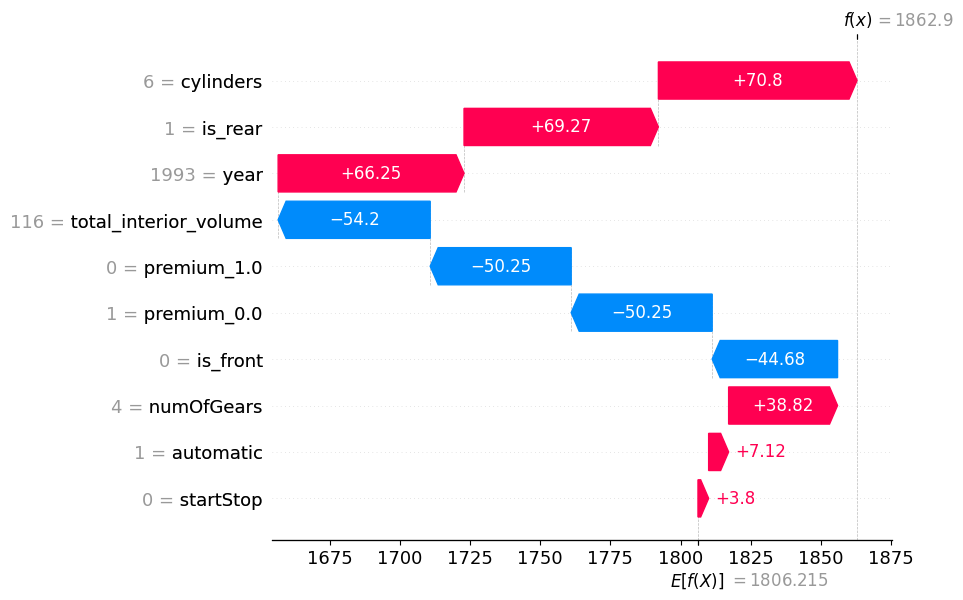

In [320]:
import shap as sh 

explainer = sh.Explainer(lin_reg.predict, sh.utils.sample(gas_cars, 100))
shap_values = explainer(gas_cars)
shap_values.feature_names = col_trans.get_feature_names_out().tolist()

sh.plots.waterfall(shap_values[60])


In [321]:
from sklearn.svm import SVR

svm = SVR(kernel='linear', C=1.5, epsilon=0.05)
svm.fit(gas_cars, y_train)

# Check how well it performs on unseen test data
print(svm.score(gas_cars, y_train))
print(svm.score(gas_cars_test, y_gas_cars_test))

0.7904263219468405
0.733864109087409


### Random Forest

In [322]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(gas_cars, y_train)

y_pred = rf_model.predict(gas_cars_test)

rf_train_score = rf_model.score(gas_cars, y_train)
print(f"Random Forest Training R-squared: {rf_train_score:.4f}")

# Check how well it performs on unseen test data
rf_test_score = rf_model.score(gas_cars_test, y_gas_cars_test)
print(f"Random Forest Test R-squared: {rf_test_score:.4f}")

Random Forest Training R-squared: 0.9350
Random Forest Test R-squared: 0.8314


## EV cars

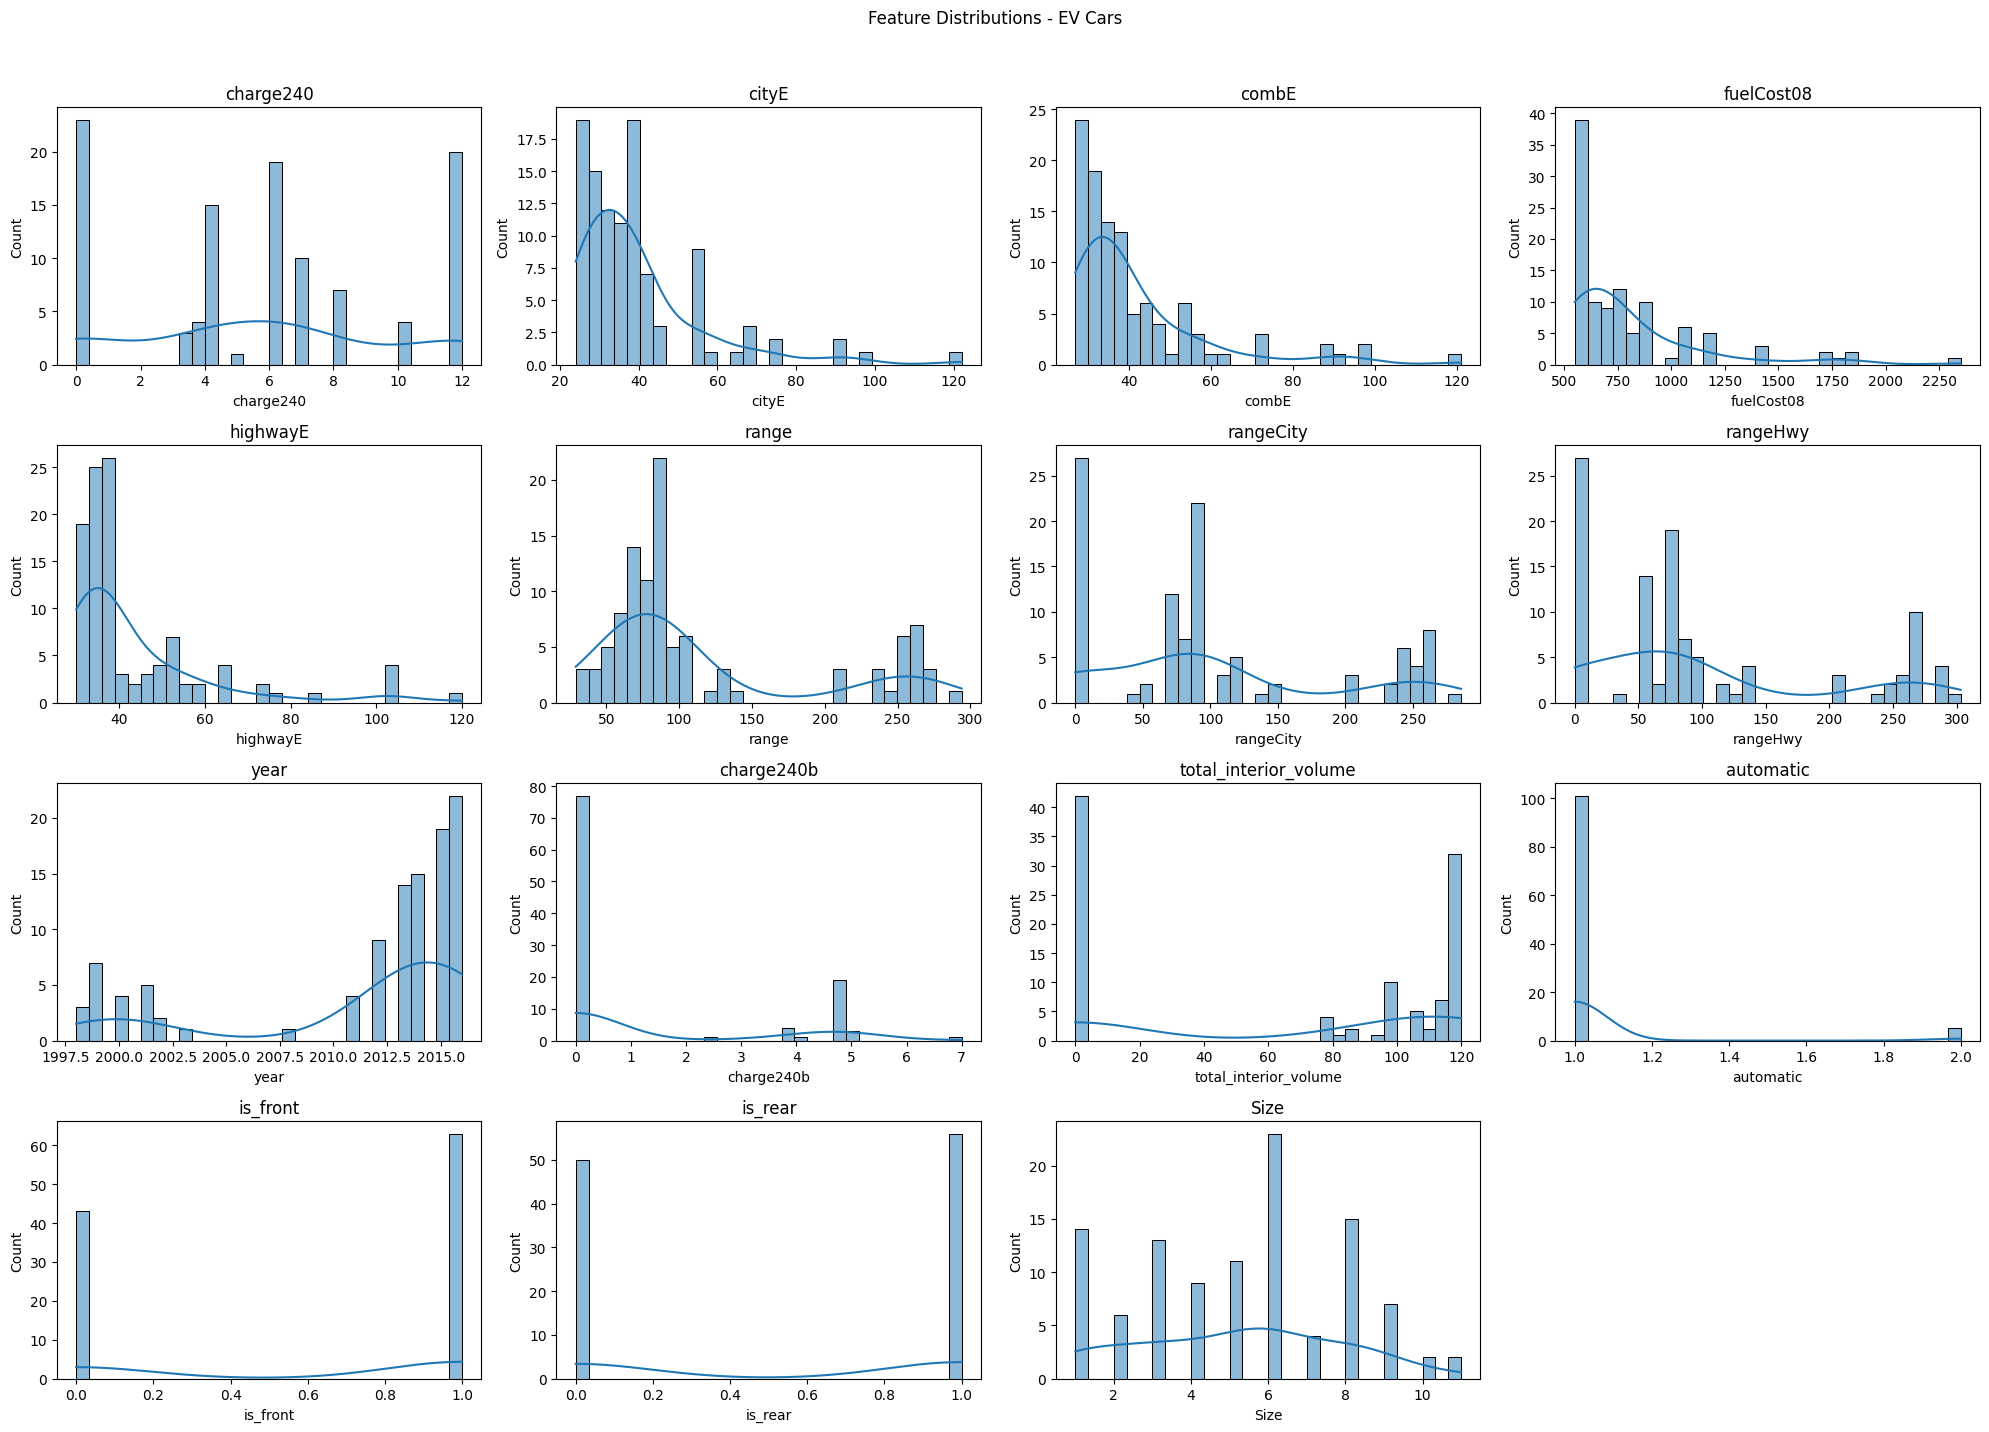

In [323]:
plot_distribution(ev_cars, "EV Cars")

In [324]:
ev_cars.columns

Index(['charge240', 'cityE', 'combE', 'fuelCost08', 'highwayE', 'make',
       'model', 'range', 'rangeCity', 'rangeHwy', 'year', 'evMotor',
       'charge240b', 'total_interior_volume', 'automatic', 'numOfGears',
       'is_front', 'is_rear', 'Size'],
      dtype='str')

We drop columns `cityE`, `highwayE` since we have a column combining both columns `combE`. We do the same for columns `rangeCity` and `rangeHwy`.

In [ ]:
ev_cars.drop(columns=['cityE', 'highwayE', 'rangeCity', 'rangeHwy'], inplace=True)
#ev_cars_test.drop(columns=['cityE', 'highwayE', 'rangeCity', 'rangeHwy'], inplace=True)

KeyError: "['cityE', 'highwayE', 'rangeCity', 'rangeHwy'] not found in axis"

We can extract how powerful the engine actually is, so we do that and after that we drop the `evMotor` column.

In [326]:
def handle_ev_motor(ev_motor: pd.DataFrame) -> int: 
	"""
	@brief Auxiliary funtion which determines the power of the EV. It either extracts the power directly, 
		   or it sums the power of all the engines the EV has.
	@param ev_motor specification of EV engine

	@return power of the car
	"""
	if pd.isna(ev_motor) or ev_motor == None:
		return -1
	elif re.match(r'(\d+ \(front\) \d+ \(rear\))|(\d+ and \d+)', ev_motor):
		powers_of_motors = re.findall(r"(\d+)", ev_motor)
		return int(powers_of_motors[0]) + int(powers_of_motors[1])
	else:
		return int(re.findall(r"(\d+)", ev_motor)[0])


def get_engine_power(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Extracts the EV engine power which is located in the evMotor attribute, stores it in a dedicated "power" column 
		   and after that it deletes the evMotor column.
    
    @param df input dataframe
    @return modified dataframe
    """
	
    df['power'] = df['evMotor'].apply(handle_ev_motor)
    df.drop(columns=['evMotor'], inplace=True)
	
    return df

ev_cars = get_engine_power(ev_cars)
#ev_cars_test = get_engine_power(ev_cars_test)

## Diesel Cars


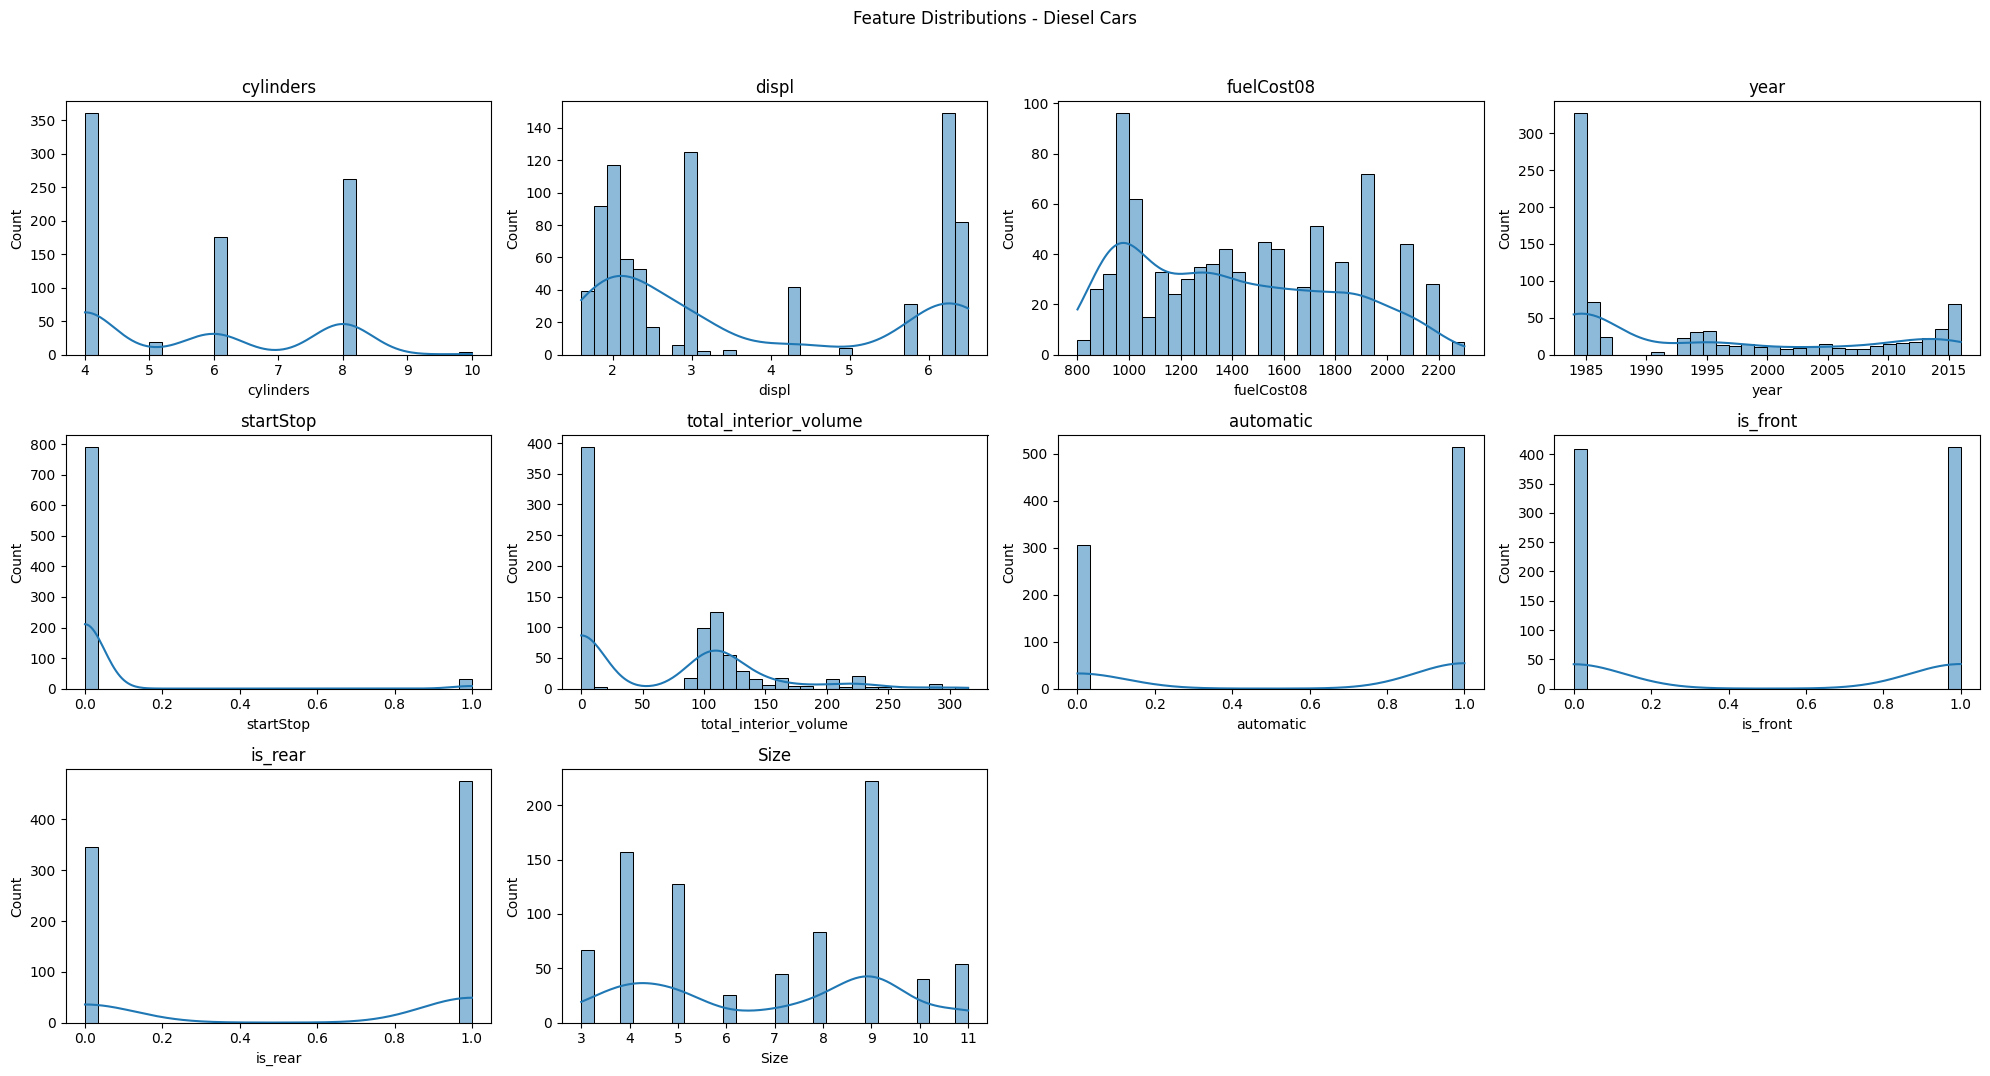

In [ ]:
plot_distribution(diesel_cars, "Diesel Cars")
